# Variant Statistics

This notebook presents validation checks and summary statistics for generated dataset variants.

## 1. Setup and data loading

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
repo_root = Path("..").resolve()
versions_root = repo_root / "data" / "processed"
version_dirs = sorted(path for path in versions_root.glob("v*") if path.is_dir())
latest_version = version_dirs[-1]
variants_dir = latest_version / "variants"

overview_path = variants_dir / "variant_overview.csv"
overview = pd.read_csv(overview_path).sort_values("variant").reset_index(drop=True)

print(f"Dataset version: {latest_version.name}")
print(f"Variants dir: {variants_dir}")
print(f"Variants listed: {len(overview)}")
overview

Dataset version: v1.0.1
Variants dir: /workspaces/config-recommendation-ml/data/processed/v1.0.1/variants
Variants listed: 5


,variant,rows,total_columns,feature_count,dropped_feature_count,dropped_features,dataset_path,manifest_path
0,corr_060,1465,38,27,5,"['forks', 'num_dirs', 'num_py_files', 'num_tes...",data/processed/v1.0.1/variants/corr_060/datase...,data/processed/v1.0.1/variants/corr_060/varian...
1,corr_070,1465,40,29,3,"['forks', 'num_dirs', 'other_extensions_count']",data/processed/v1.0.1/variants/corr_070/datase...,data/processed/v1.0.1/variants/corr_070/varian...
2,dom_080,1465,39,28,4,"['has_license', 'has_src_dir', 'num_ts_files',...",data/processed/v1.0.1/variants/dom_080/dataset...,data/processed/v1.0.1/variants/dom_080/variant...
3,manual_selection,1465,40,29,3,"['avg_files_per_dir', 'avg_nb_cell_count', 'ha...",data/processed/v1.0.1/variants/manual_selectio...,data/processed/v1.0.1/variants/manual_selectio...
4,original,1465,43,32,0,[],data/processed/v1.0.1/variants/original/datase...,data/processed/v1.0.1/variants/original/varian...


## 2. Summary statistics

In [3]:
stats = overview[["variant", "feature_count", "dropped_feature_count", "rows"]].copy()
stats["retention_ratio"] = (
    stats["feature_count"] / stats["feature_count"].max()
).round(3)
stats["drop_ratio"] = (
    stats["dropped_feature_count"] / stats["feature_count"].max()
).round(3)
stats

,variant,feature_count,dropped_feature_count,rows,retention_ratio,drop_ratio
0,corr_060,27,5,1465,0.844,0.156
1,corr_070,29,3,1465,0.906,0.094
2,dom_080,28,4,1465,0.875,0.125
3,manual_selection,29,3,1465,0.906,0.094
4,original,32,0,1465,1.000,0.000


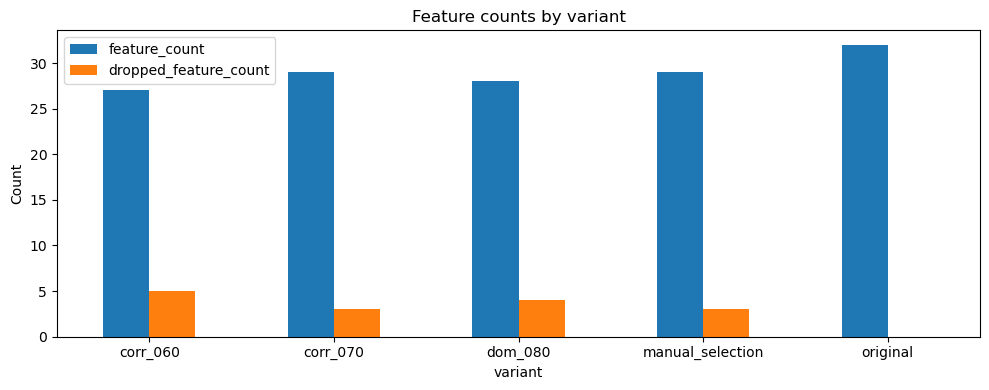

In [4]:
ax = stats.plot(
    x="variant",
    y=["feature_count", "dropped_feature_count"],
    kind="bar",
    figsize=(10, 4),
    title="Feature counts by variant",
)
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()